# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1.

정상성이란 시계열 데이터가 시점에 따라 평균 같은 통계적 특징이 변하지 않고 추세가 계절성이 없는 시계열 데이터를 의미한다. 즉 정상성을 가진 시계열 데이터는 시차가 커질수록 관계성이 감소한다. 시계열 데이터에서 정상성이 중요한 이유는 평균과 분산이 다른 비정상성의 경우 미래의 값을 예측할 수 없기 때문이다.

ARIMA 모델에서는 차분을 통해 비정상성을 처리한다.
차분이란 현재 시점의 데이터에서 이전 시점의 데이터를 빼는 것으로 이를 통해 데이터에 존재하는 일정한 증감 추세가 제거되어 평균을 안정화할 수 있고 이로 인해 비정상 시계열 데이터를 모델이 학습 할 수 있도록 해주는 역할을 한다.


Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.

해당 시계열은 비정상 시계열이다.

정상성을 가지는 시계열이라면 과거 데이터는 시차가 클수록 영향력이 감소하므로 ACF가 급격히 감소해야 하지만 문제에서는 천천히 감소하고 1시차에서 PCAF가 큰값을 가지고 점진적으로 감소한다고 하였으므로 이는 데이터에 추세가 존재하거나 과거의 영향력이 길게 유지되는 것이다.

즉 비정상 시계열로 볼 수 있다.
<br>

'분산은 시간에 따라 변하지 않음' 이라는 조건은 시계열의 비정상성이 추세의 불안정성에 따른다는 것을 의미하며 로그변환 등을 수행하지 않아도 된다.

실제로 1차 차분 후 ACF가 절단 형태를 보였고 PACF가 점진적으로 감소하였다는 문제의 보기를 통해 비정상성을 가진 시계열임을 알 수 있다.

따라서 이 문제에서 적절한 모형은 ARIMA 모형으로 이는 보기처럼 1차차분 후 MA 모형의 특성을 보여주고 있기 때문이다.


## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weatherww2' dataset.
Path to dataset files: /kaggle/input/weatherww2


In [4]:
# kaggle 기본 제공 코드
import os

path = "/kaggle/input/weatherww2"

print(os.listdir(path))

['Summary of Weather.csv', 'Weather Station Locations.csv', '.nfs000000007ecfbceb0000004f']


In [5]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/kaggle/input/weatherww2/Weather Station Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [6]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/kaggle/input/weatherww2/Summary of Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_186/1049732682.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/kaggle/input/weatherww2/Summary of Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [ ]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_776/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_776/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


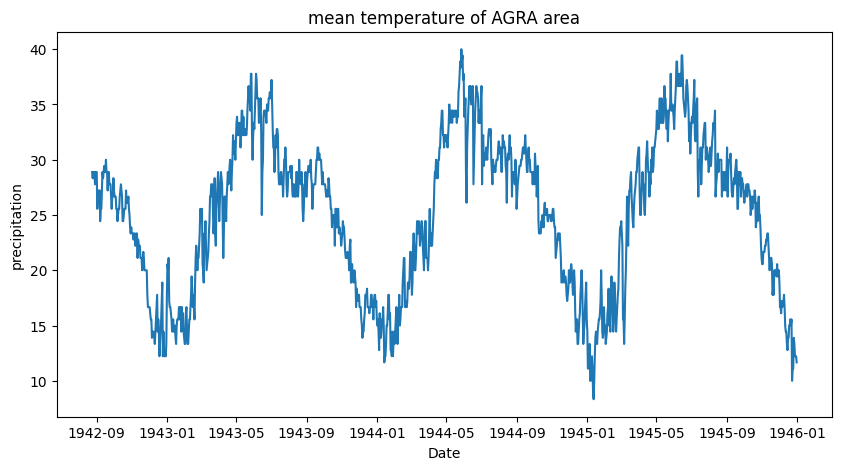

In [ ]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [ ]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

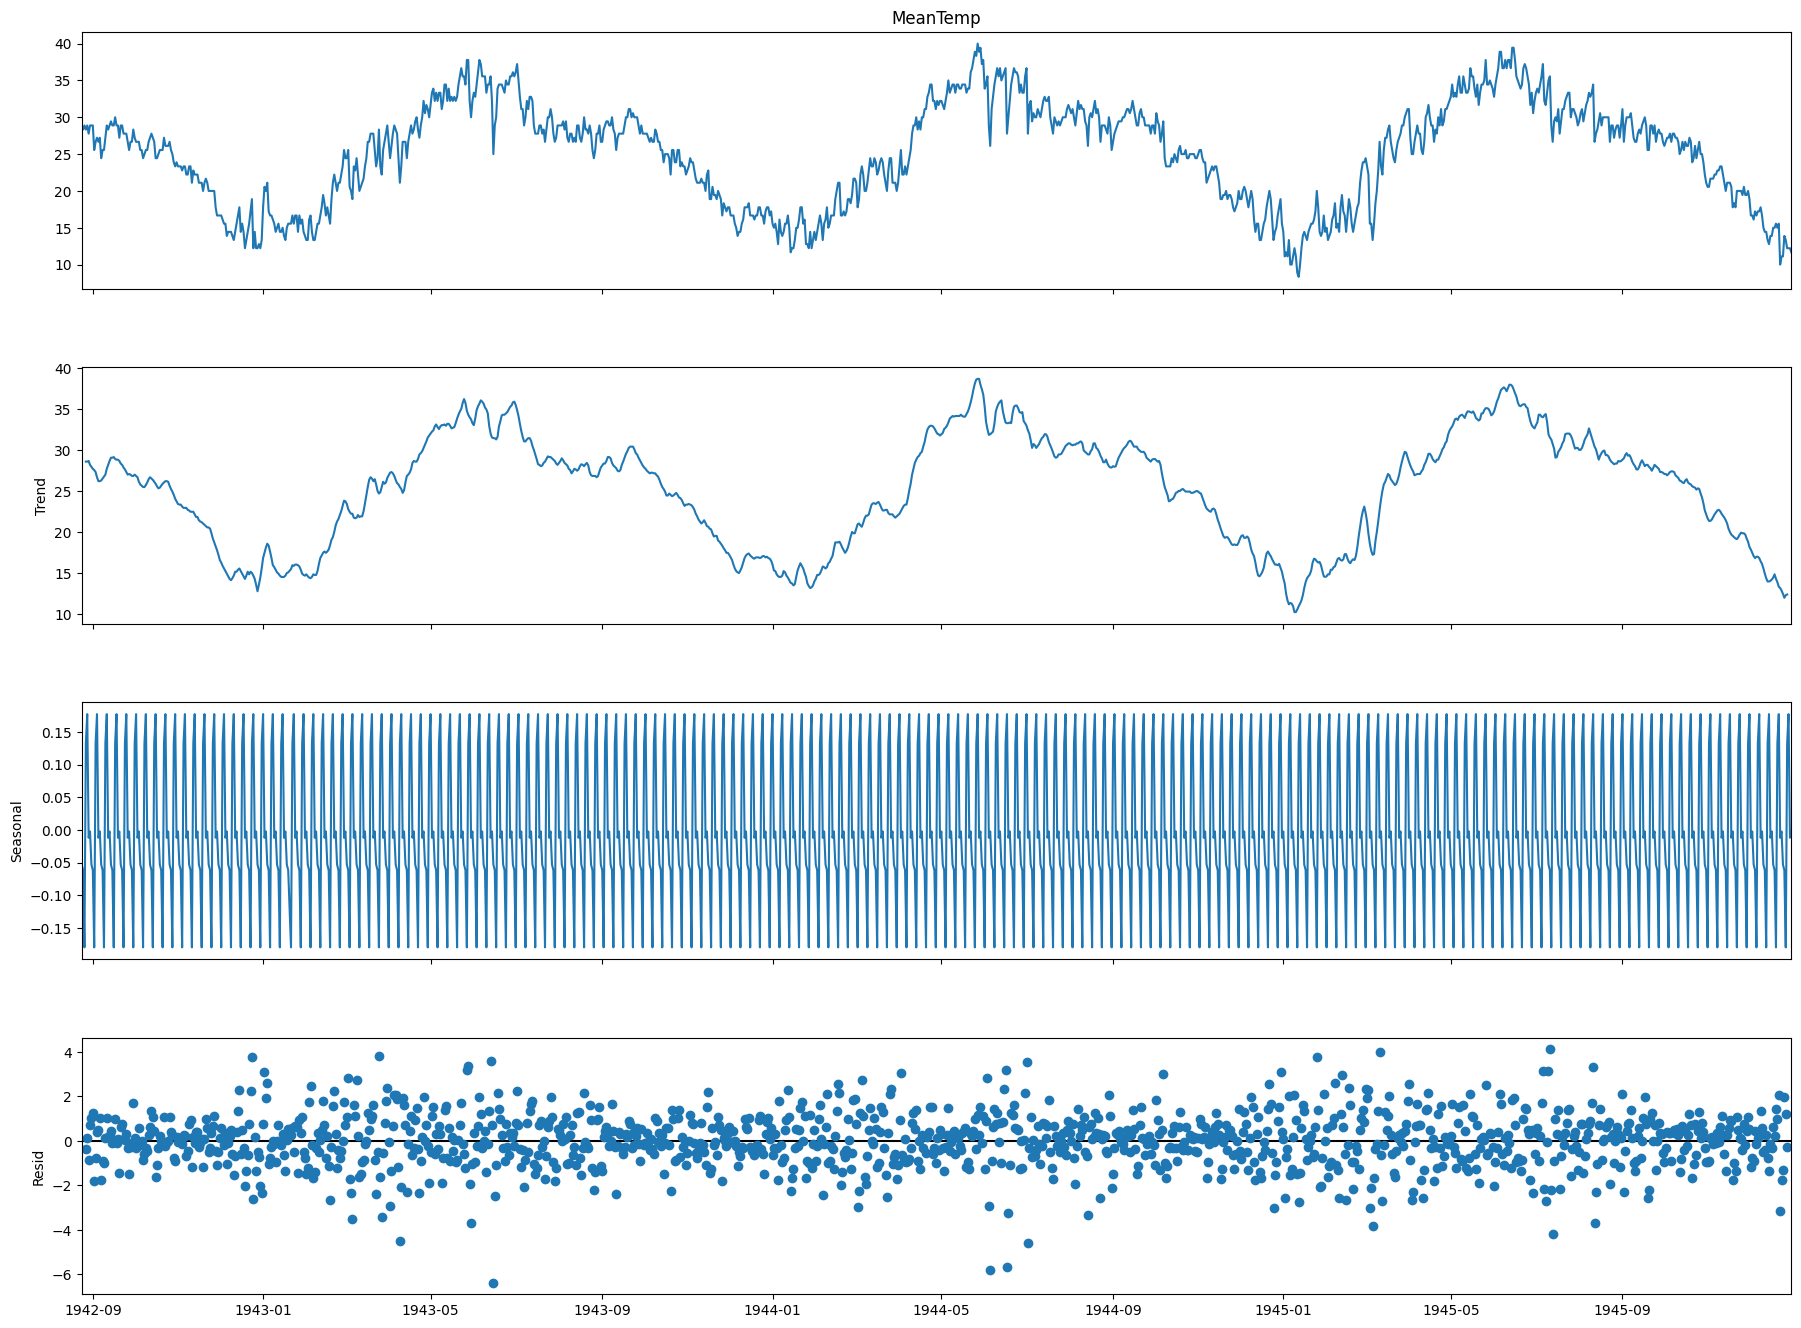

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

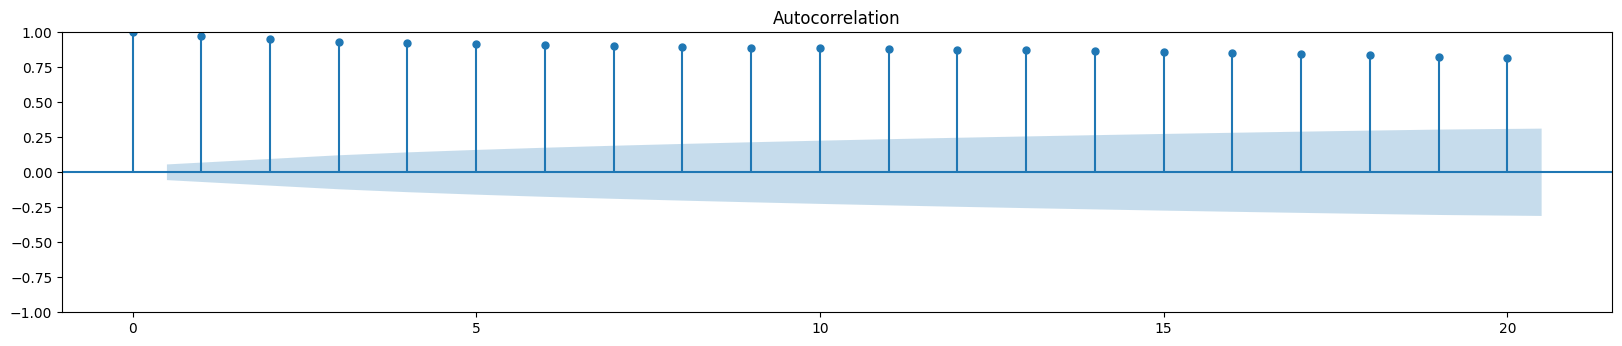

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.

**귀무가설 :**

이 데이터는 비정상 시계열이다.

**대립가설 :**

이 데이터는 정상 시계열이다.

<br>

위 결과에서 p-value 값이 유의수준 0.05 이하라면 귀무가설을 기각하고 대립가설을 채택해 현재 활용하는 데이터가 정상 시계열이라 볼 수 있다.

만약 아니라면 귀무가설을 기각할 수 없으므로 비정상 시계열이라고 봐야한다.

그러나 위의 결과를 보면 p-value 값은 약 0.25로 귀무가설을 기각할 수 없다.

**따라서 이 데이터는 비정상 시계열로 봐야한다.**

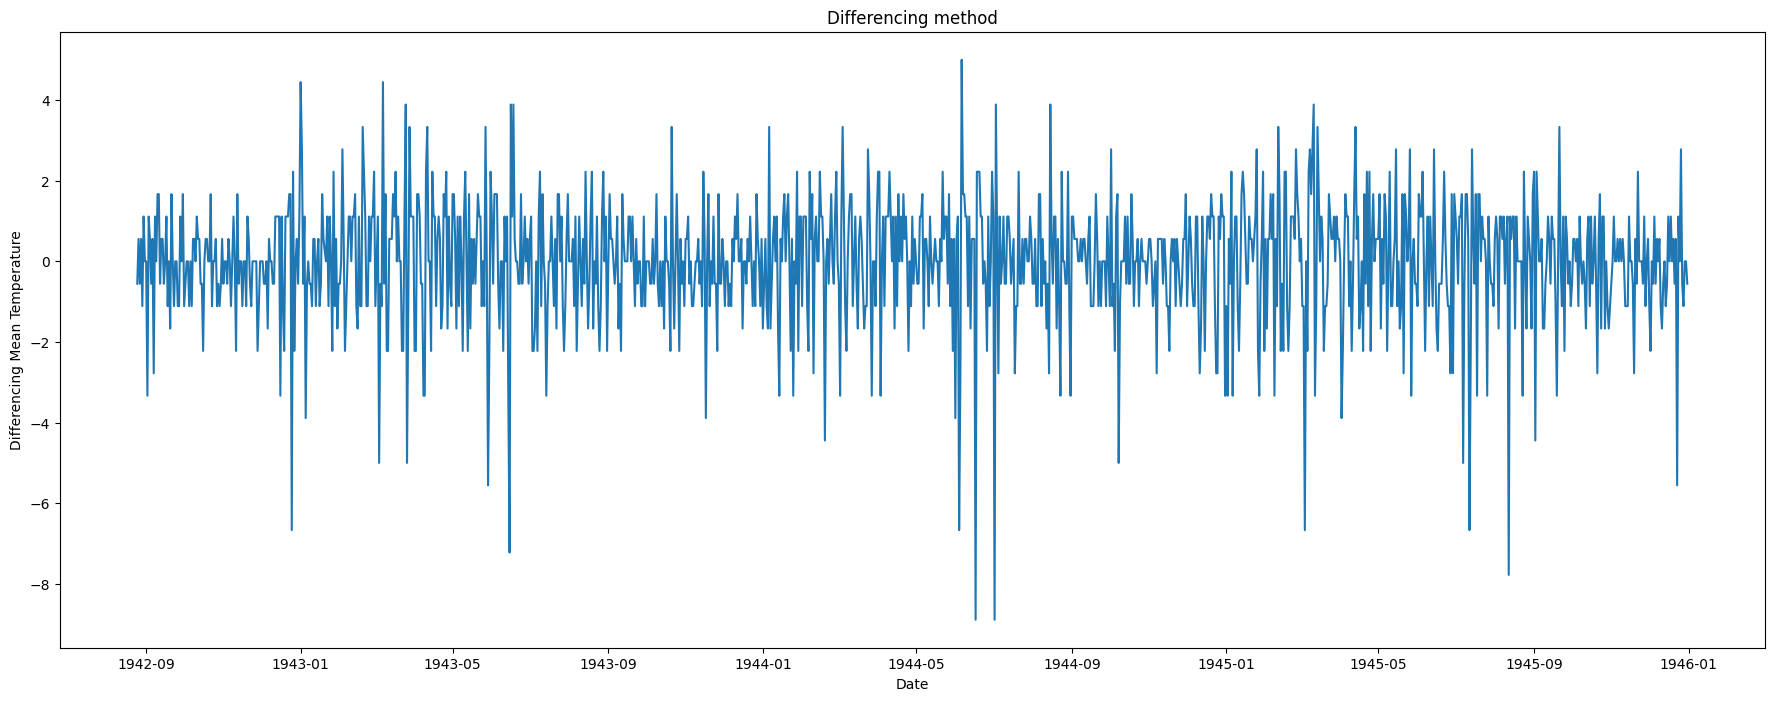

In [ ]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [ ]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.

앞의 결과에서는 귀무가설을 기각하지 못했다.
즉 데이터가 비정상 시계열임을 알 수 있었다.


이번 결과에서는 p-value 값이 유의수준 0.05 보다 작은 0이 나왔으므로 귀무가설을 기각할 수 있다.
**즉 정상 시계열로 변환되었음을 알 수 있다.**


해당 원인은 **ts - ts.shift()** 코드에 있으며 이는 차분을 수행하는 코드이다.

**차분**은 현재 시점 t의 관측치에서 t-1 시점의 관측치를 빼는 연산으로 아래와 같이 수행된다.

$$y'_t = y_t - y_{t-1}$$
<br>


따라서 이번 결과에서는 1차차분을 수행해 앞에서 보았던 시계열 데이터의 불규칙한 추세와 비정상성 유발 원인들을 제거했다.

이로 인해 p-value 값이 감소했으며 정상 시계열로 변환된 것이다.

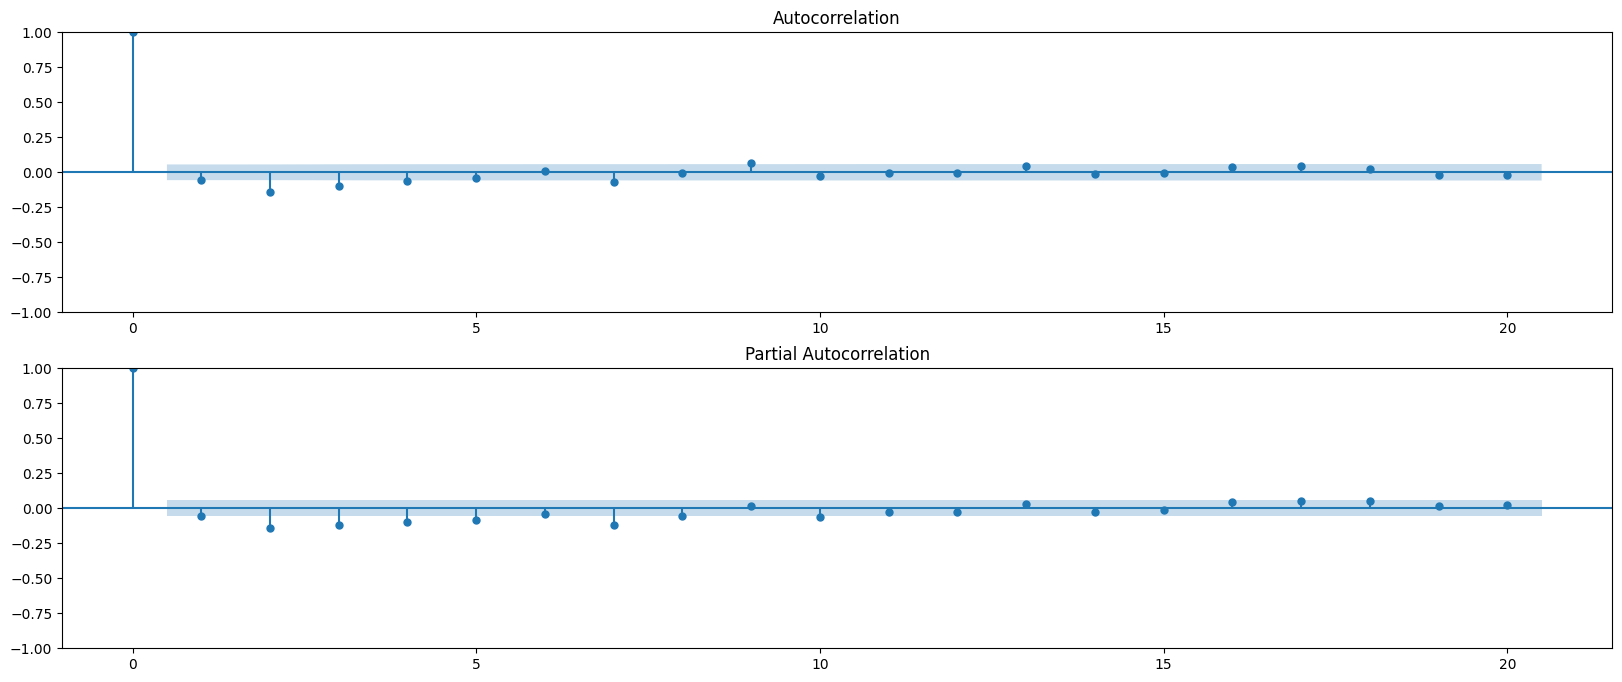

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.

첫번째 그래프는 **ACF 그래프**로 t 와 t-k 시점 간 상관관계를 나타내는 그래프이다.

 MA 성향여부와 q의 값을 정하는데 활용할 수 있다.

두번째 그래프는 **PACF 그래프**로 t 와 t-k 시점 사이의 다른 시점들의 영향은 제외하고 두 시점 간 상관관계를 측정한 그래프이다.

AR 성향을 확인하고 p의 값을 결정하는데 활용할 수 있다.



<br> 하이퍼파라미터 p 와 q 값을 찾기 위해 아래 두가지를 확인해봐야한다.
1) 특정 시차 이후 그래프가 신뢰구간(파란색부분) 안으로 감소해 0에 가까워지는지
2) 점진적으로 감소하는지

<br>

ACF 그래프에서는 1에서 단절이 일어났다. 따라서 q 를 0으로 설정한다.

마찬가지로 PACF 그래프에서도 1에서 단절이 일어났다. 따라서 p 를 1로 설정한다.


### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


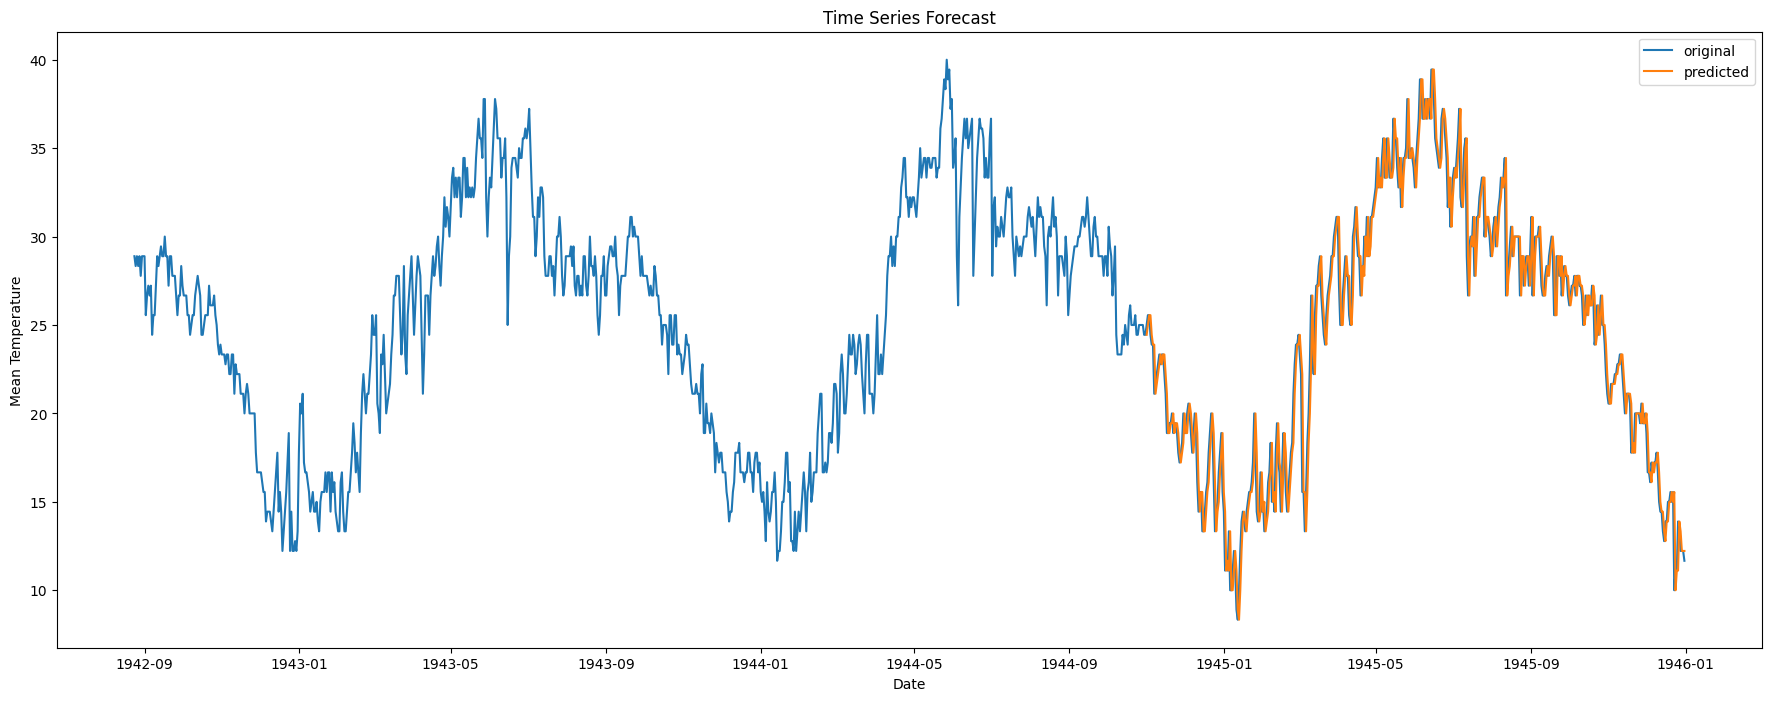

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_776/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


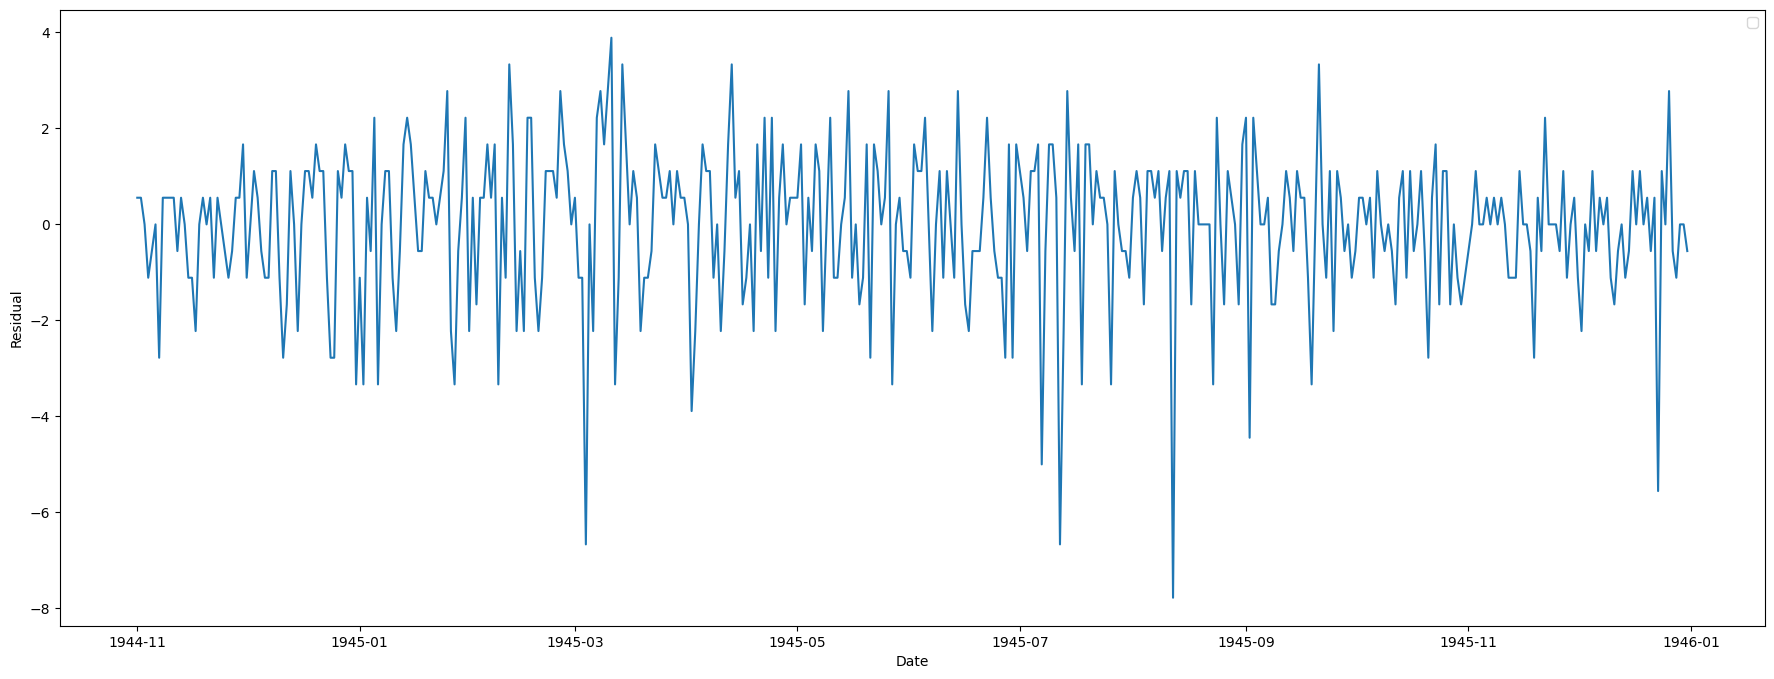

In [ ]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

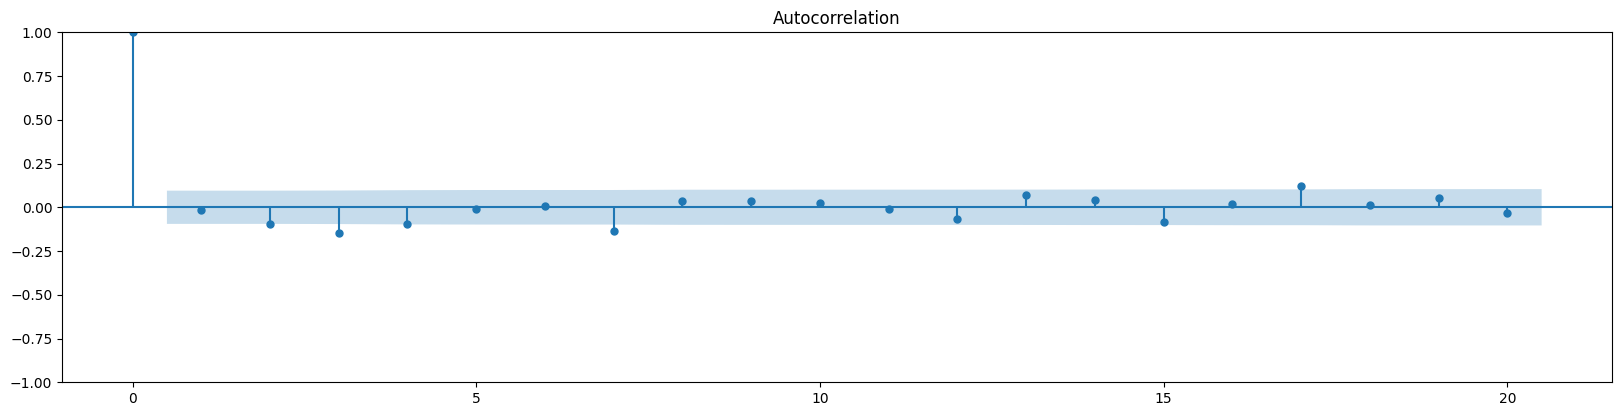

In [ ]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [ ]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.375983
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [ ]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [ ]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.56,0.978,1.565,5.366


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.

위의 결과들을 보면 먼저 잔차그래프에서는 일정한 패턴이 보이지 않으므로 안정적이라 판단할 수 있다. 특히 ACF 그래프 또한 신뢰구간안에 모든 점들이 들어와있다. 이를 통해 잔차들 간 상관관계가 없다고 생각해볼 수 있다.

ADF Test 에서는 p-value 값이 유의수준인 0.05 보다 훨씬 작고 statistic 값도 1% 기준치보다 작아 위에서 설계한 귀무가설을 기각할 수 있다.

따라서 정상성을 만족한다.


R2 값이 약 96%로 예측률이 높음을 알 수 있다. 또한 상관계수가 1에 가깝고 RMSE의 값을 볼때 오차범위도 작음을 알 수 있다. <br>
마지막으로 MAPE 가 5%에 불과하므로 좋은 모델이라고 볼 수 있다.


### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.



| Index | R2 | Corr | RMSE | MAPE |
| :--- | :--- | :--- | :--- | :--- |
| epoch: 10, learning_rate: 0.01, kernel_size: 365| 76.902 | 0.906 | 3.318 | 10.437 |
epoch: 20, learning_rate: 0.01, kernel_size: 365|	28.847 |	0.76 |	5.824	| 17.811 |
epoch: 10, learning_rate: 0.001, kernel_size: 365 | 87.537 |	0.941 |	2.437	 |7.59 |
epoch: 20, learning_rate: 0.001, kernel_size: 365 | 88.87 |	0.947 |	2.303	 |7.47|
epoch: 30, learning_rate: 0.001, kernel_size: 365 | 88.639 |	0.943 | 	2.327	 |7.039
epoch: 30, learning_rate: 0.001, kernel_size: 25 | 81.533	| 0.917 | 	2.967 |	9.757 |
epoch: 30, learning_rate: 0.001, kernel_size: 7 | 88.135	| 0.943	| 2.378	| 7.344|
**epoch: 20, learning_rate: 0.001, kernel_size: 7**  | **90.027**  |	**0.951**  |	**2.18**  |	**7.012** |
**epoch: 20, learning_rate: 0.0005, kernel_size: 7** |	**90.449** | **0.952** |	**2.134** |	**6.579**

<br>

**1. learning_rate 탐색 :**
초기설정값에서는 R2 score가 76으로 좋지 않았으며 epoch 을 20으로 변경했을때 28의 값을 나타낸 것으로 보아 learning_rate 를 낮춰보려는 선택을 해보았다.

**2. epoch 탐색 :**
learning_rate 를 0.001로 낮춘결과 성능이 초기보다 크게 향상 되었으며 이를 고정하고 epoch 값을 100까지 탐색해보았다. 20~30 부분에서 과적합 없이 성능이 제일 좋은 것을 확인했다.


**3. Kernel_size 탐색 :**
2까지의 과정을 진행하며 kernel_size 값을 25(월별), 7(주별) 로 각각 변경해보았다. 7인 경우에 성능을 높게 달성하는 것을 볼 수 있었다.

이를 활용해 learning_rate 를 0.0005로 한번 낮춰보았을때, 최고의 성능을 나타냈다.



---

이번 데이터셋에서는 ARIMA 보다 DLinear 모델이 적합하다.

ARIMA 는 AR 과 MR을 동시에 활용해 현재값을 예측하는 모델이다. 그러나 예측이 반복될수록 오차가 누적되어 장기 예측에서 성능이 저하될 수 있고, 정상시계열을 가질때 활용할 수 있어 비정상 시계열의 차분과정에서 데이터의 장기성 구조가 손실 될 수 있다.

반면 DLinear 모델은 Trend 와 Seasonal 요소로 시계열을 분할하고 이를 선형 레이어에 통과시킨다. 특히 장기예측에 탁월해 날씨 데이터처럼 추세가 뚜렷하면 좋은 성능을 낸다.

우리가 활용하는 데이터셋도 날씨데이터이므로 Dlinear 에 더 적합하다.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [ ]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=25):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [ ]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

epochs = 30

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.004324
Epoch 20, Loss: 0.003463
Epoch 30, Loss: 0.003390


In [ ]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

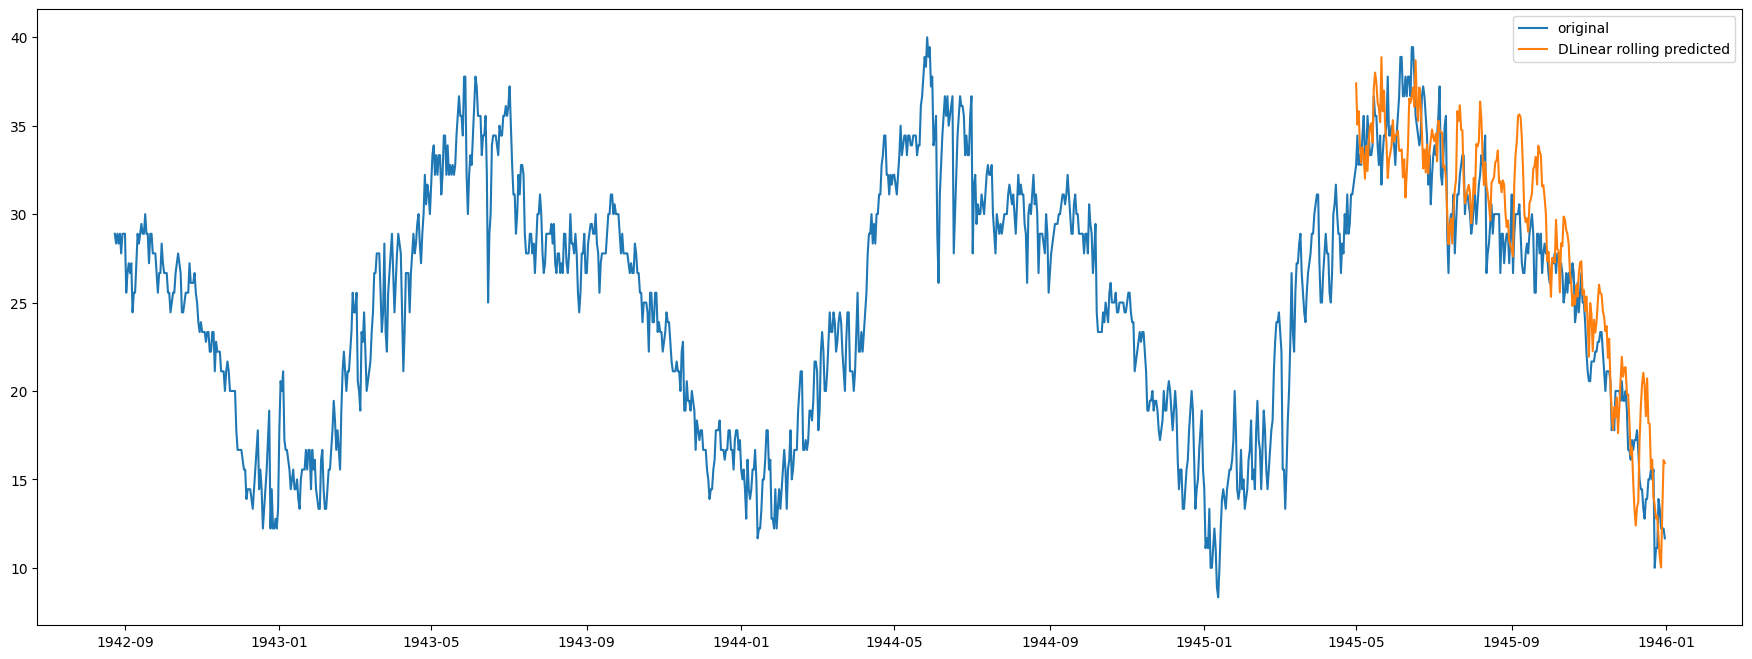

In [ ]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [ ]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,82.751,0.925,2.867,9.373


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.



> ###  데이터 준비
이번 분석에서는 **GAYA의 강수량**을 활용해 분석과정을 수행합니다. (위에서 기온값 분석을 진행했기 때문)


In [88]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


In [273]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "GAYA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_186/2193832096.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_186/2193832096.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
74513,32805,1942-11-22,28.888889,14.444444,21.666667,0.000
74514,32805,1942-11-23,28.888889,13.888889,21.111111,0.000
74515,32805,1942-11-24,28.888889,13.333333,21.111111,0.000
74516,32805,1942-11-25,28.333333,12.222222,20.000000,0.000
74517,32805,1942-11-26,27.777778,12.222222,20.000000,0.000
...,...,...,...,...,...,...
75643,32805,1945-12-27,19.444444,12.777778,16.111111,0.762
75644,32805,1945-12-28,17.777778,9.444444,13.333333,0.100
75645,32805,1945-12-29,21.111111,6.666667,13.888889,0.000
75646,32805,1945-12-30,20.000000,6.666667,13.333333,0.000


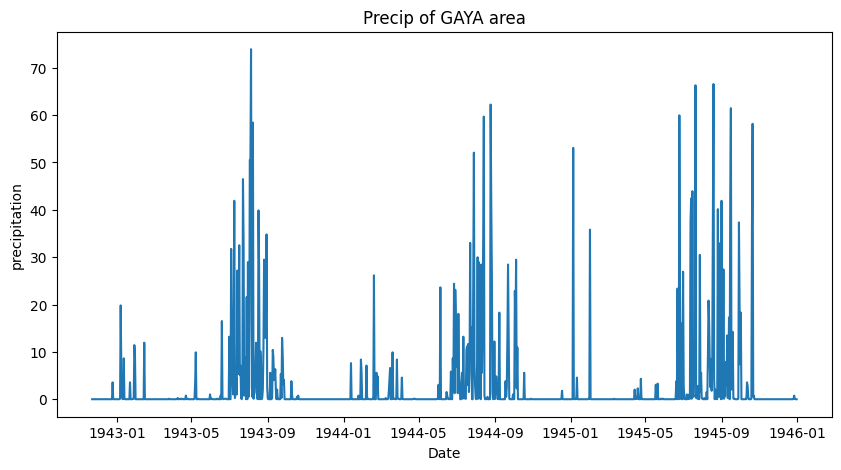

In [274]:
# 해당 지역의 강수량 그래프
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.Precip)
plt.title("Precip of GAYA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [275]:
timeSeries = weather_bin.loc[:, ["Date", "Precip"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,Precip
Date,
1942-11-22,0.000
1942-11-23,0.000
1942-11-24,0.000
1942-11-25,0.000
1942-11-26,0.000
...,...
1945-12-27,0.762
1945-12-28,0.100
1945-12-29,0.000


<Figure size 640x480 with 0 Axes>

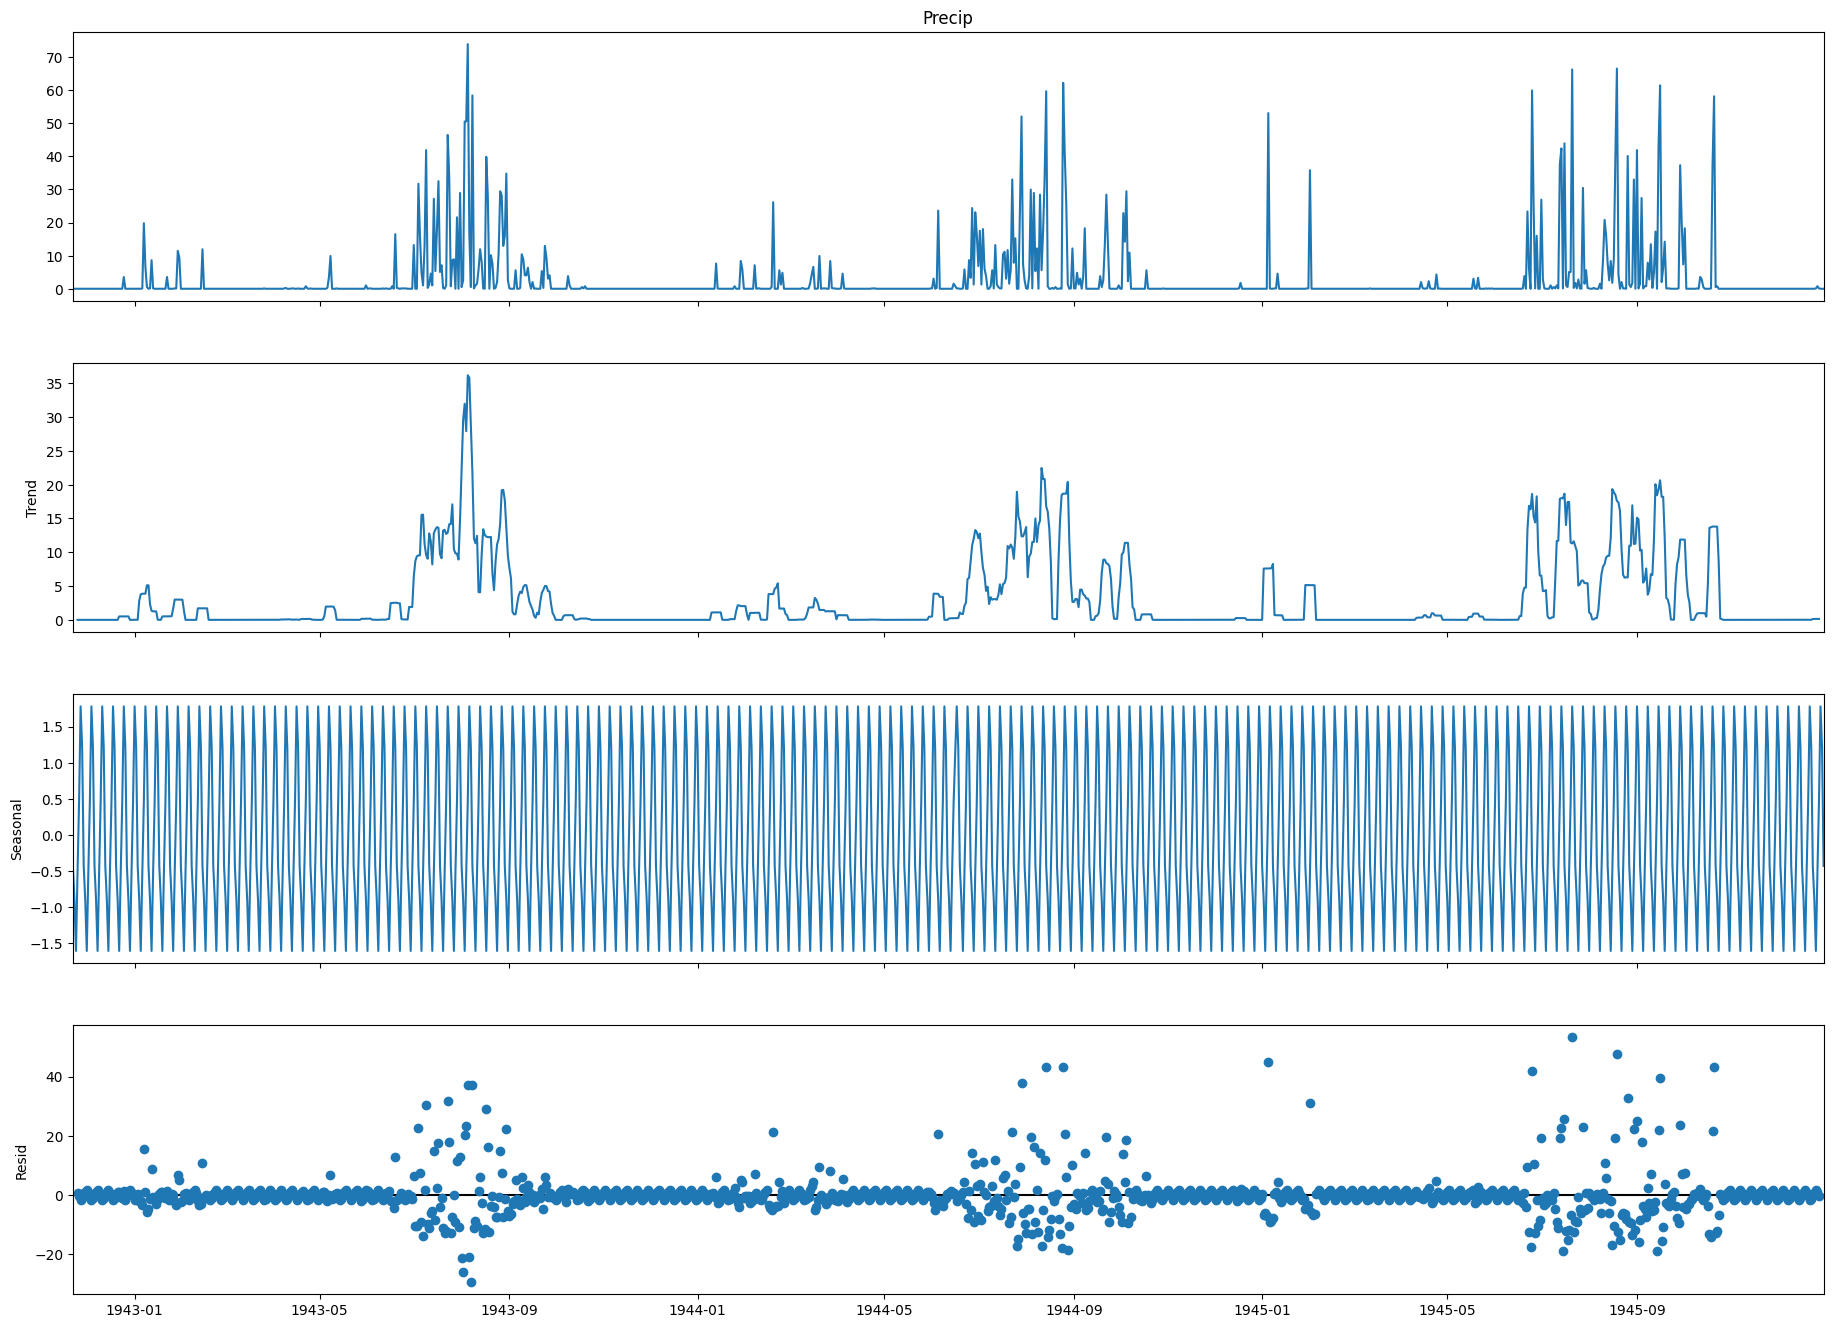

In [276]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["Precip"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)



> ###  정상성 판단



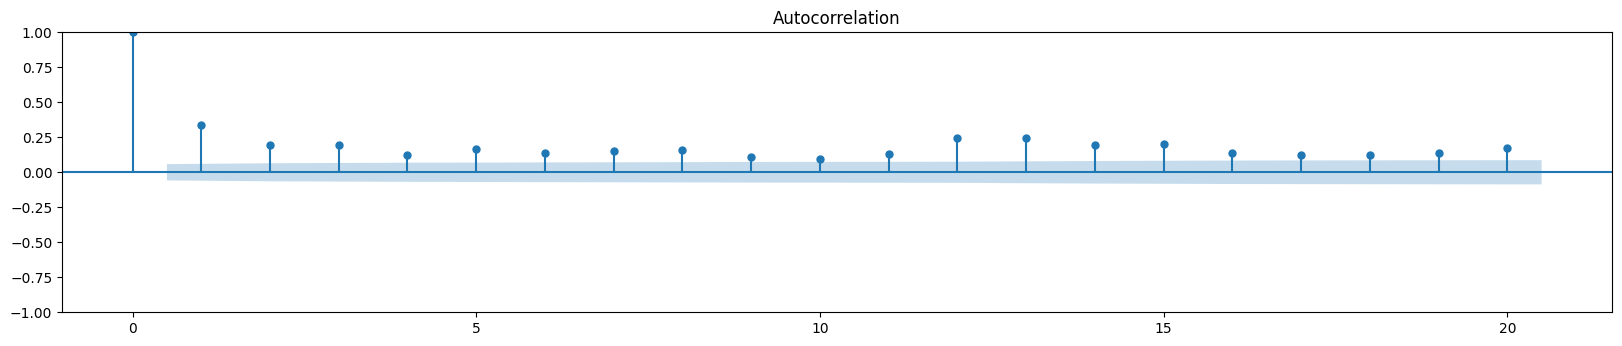

In [277]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [278]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.467198
p-value: 0.008871
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


위 결과를 보면 p-value 가 0.008로 유의수준인 0.05보다 낮다.

따라서 귀무가설(이 데이터는 비정상 시계열이다)를 기각할 수 있다.

이 데이터는 정상 시계열이다. 따라서 ARIMA 분석을 수행해보도록 한다.

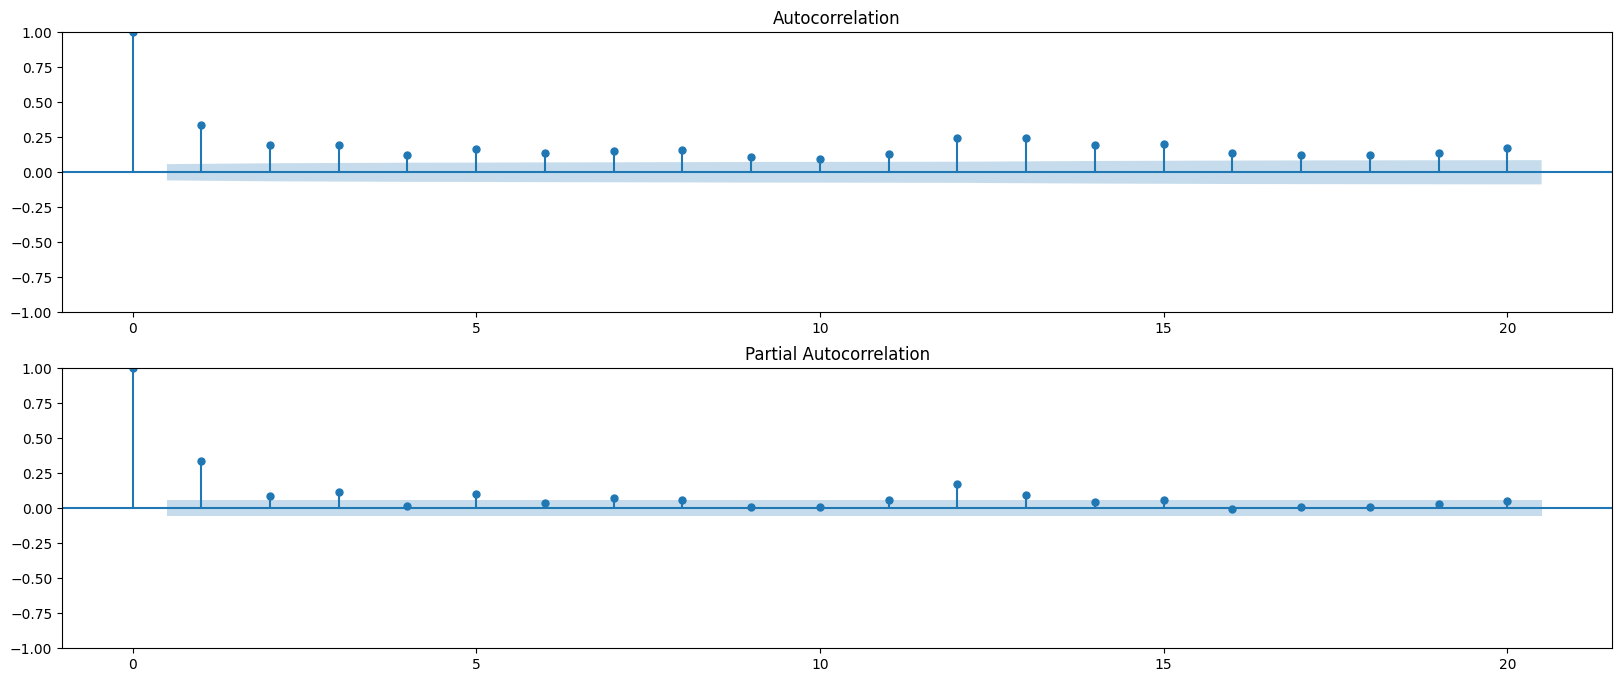

In [289]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts, lags=20, ax=ax2)

✅ P : 위의 PACF 그래프를 볼 때, lag1 이후 절단되어 신뢰구간 내에 위치하고 있으므로 p = 1 으로 설정

✅ Q : ACF 그래프에서 시차 0 이후 신뢰구간을 벗어나는 유의미한 상관성이 없으므로 q = 0으로 설정

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


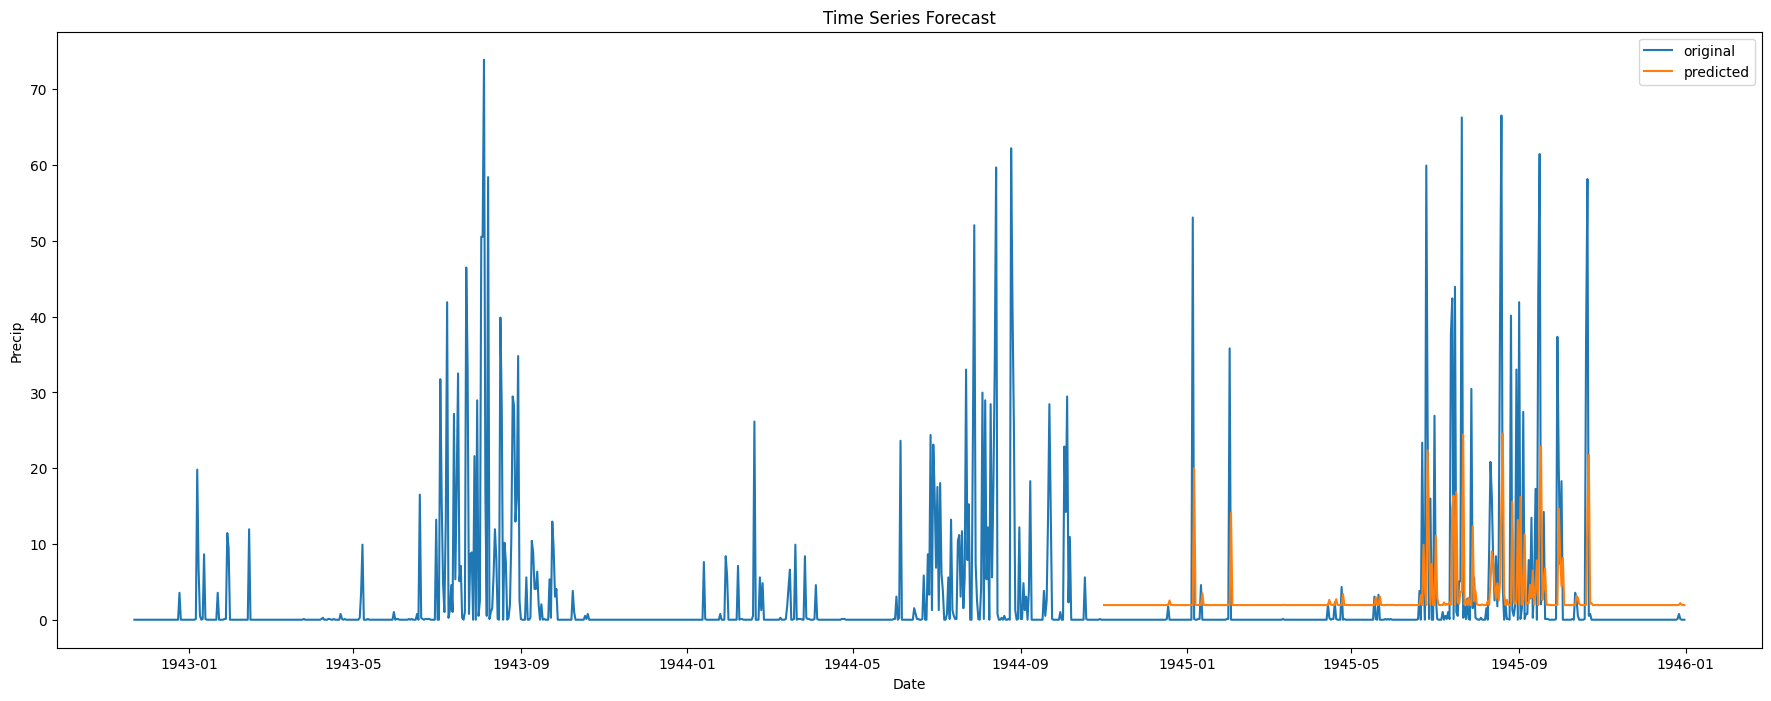

In [290]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 0
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.Precip, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Precip")
plt.legend()
plt.show()

/tmp/ipykernel_186/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


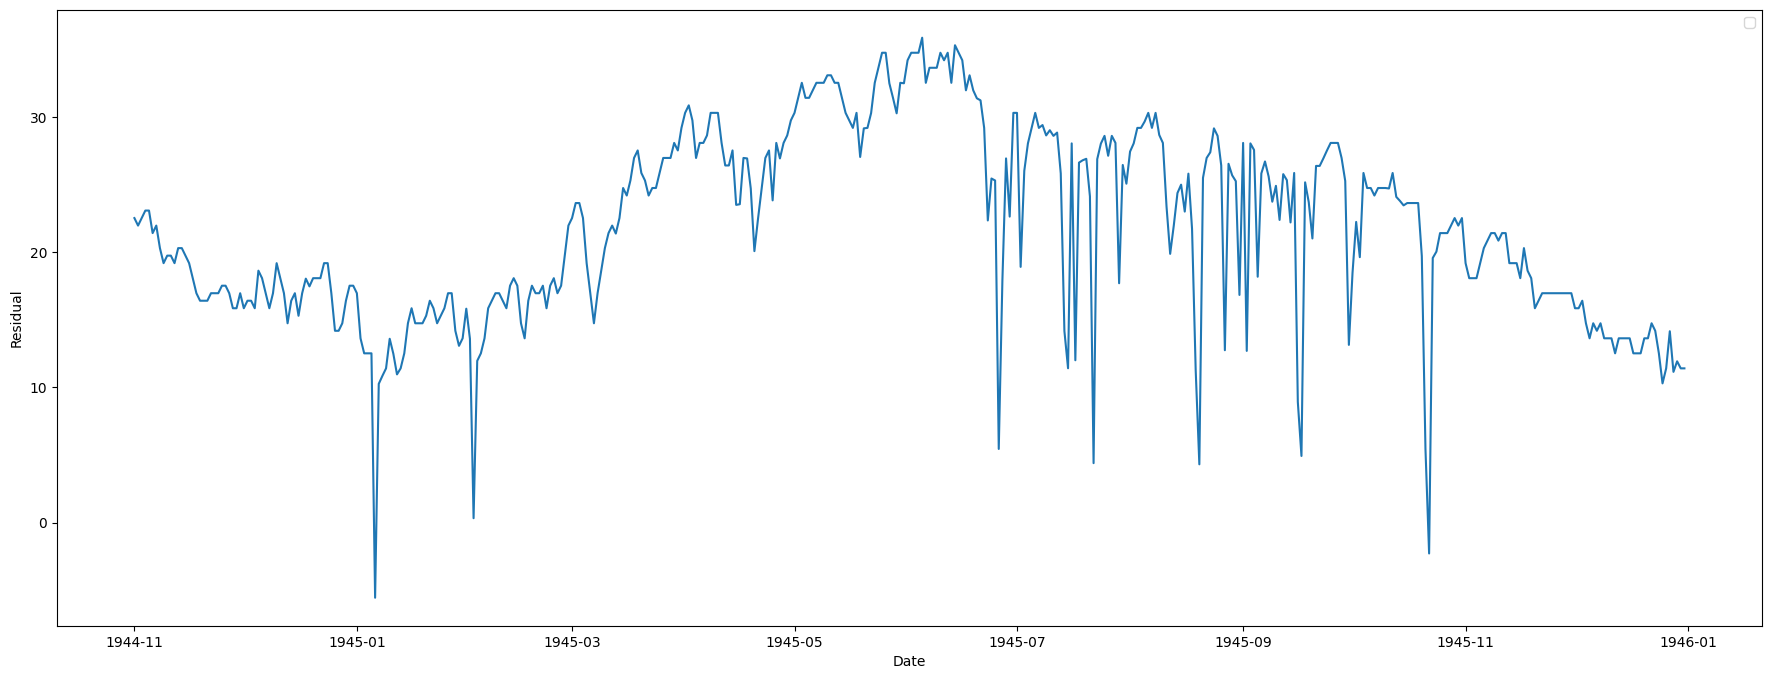

In [291]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

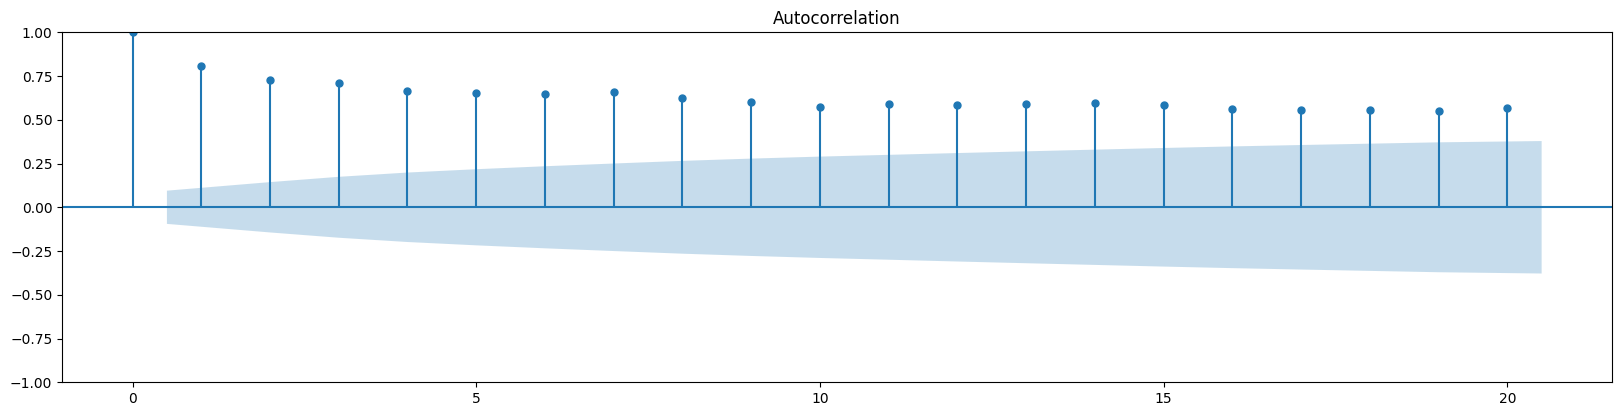

In [293]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [294]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.719870
p-value: 0.420905
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.570


In [295]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  # mae = round(metrics.mean_absolute_error(y_true, y_pred), 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [296]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,-1159.597,0.092,22.856,87.961


###  ✅ ARIMA 결과 분석

위의 결과를 볼때 ARIMA 모델을 활용한 경우 전혀 강수량을 예측하지 못하고 있는 것을 보여준다.

특히 상관계수가 0.092 로 예측량과 실제값 간 패턴의 일치성이 0에 수렴하는 것으로 보인다.



> ### [인사이트 도출]

추가실습을 통해 강수량 분석을 한 결과 다음과 같은 인사이트를 도출할 수 있다.


<br> **강수량은 기온값 분석과 다르게 ARIMA 에서 성능이 낮은 이유?**

기온량은 연속성을 보여주는 데이터인 반면 강수량은 불연속적인 데이터이다.
이는 위에서 시각화를 통해 확인할 수 있다.

반면 ARIMA 모델은 연속적인 수치의 흐름을 추적하는데 적합하다. 이 때문에 강수량 같이 갑작스러운 값 변화를 가지는 데이터는 정상성을 이루기 어렵다. 따라서 위의 결과처럼 성능이 좋지 않다.


또한 과거 값들의 선형결합을 통해 미래를 예측하는 ARIMA 모델에서는 강수량 같은 비규칙적인 값은 이를 활용할 수 없어 한계의 요인으로 작용한다.


특히 강수량의 경우 온도나 기압 구름양 등 다양한 데이터를 기반으로 예측을 해야 정확하게 예측할 수 있다. 그러나 ARIMA 는 이를 활용할 수 없다.


또한 위의 시각화 그래프에서 볼 수 있듯이 어느정도의 계절성은 있으나 불규칙하기 때문에 ARIMA 에서의 성능이 떨어지는 것이다.


위의 이유로 강수량 분석의 경우 DLinear 모델이나 다변량 모델 등을 활용해야 한다.

